# ANALISIS EXPLAINABILITY TIME SERIES FORECASTING

## 1. Topik Analisis Prediksi
Analisis prediksi dalam studi kasus ini menggunakan dataset vic_electricity dari pustaka Skforecast (Versi 0.15.1). Fokus utama dari analisis ini adalah meramal total permintaan energi listrik harian (Daily Electricity Demand) di wilayah Victoria, Australia.

Selain memprediksi nilai konsumsi listrik di
masa mendatang, tujuan inti dari eksperimen
ini adalah menerapkan aspek Explainable AI (XAI) menggunakan metode SHAP dan Partial Dependence Plot (PDP). Melalui pendekatan ini, kita dapat membongkar model "kotak hitam" (black box) untuk memahami secara logis alasan di balik keputusan model: fitur masa lalu mana yang paling dominan serta bagaimana dampak fluktuasi suhu udara harian dalam memengaruhi lonjakan beban listrik masyarakat.

## 2. Struktur Data Mentah dan Data Pelatihan
Sebelum proses pemodelan dimulai, data mentah harus ditransformasi menjadi format yang sesuai untuk pembelajaran mesin. Gambar di bawah ini menunjukkan transformasi tersebut: bagian atas adalah data mentah per 30 menit (frekuensi '30T'), dan bagian bawah adalah data yang telah di-resample ke frekuensi harian ('D') setelah agregasi permintaan (sum) dan suhu (mean).

Setelah agregasi, data deret waktu harian diubah menjadi format matriks pembelajaran terpantau (supervised learning) menggunakan fungsi internal create_train_X_y() sebelum dimasukkan ke dalam algoritma regresi pohon keputusan LGBMRegressor.

### A. Input (Features / Prediktor)
* Lags (lag_1 sampai lag_7): Nilai historis akumulasi permintaan listrik dari 1 hingga 7 hari sebelumnya.
* Exogenous Variable (Temperature): Faktor
eksternal berupa rata-rata suhu udara harian pada hari yang bersangkutan.

### B. Output (Target)
* Demand ($t+1$): Total nilai permintaan energi listrik harian pada langkah waktu berikutnya yang menjadi target prediksi model.

##3. Konsep Lag dalam Time Series Forecasting
Dalam pemodelan deret waktu, Lag adalah representasi nilai variabel target pada langkah waktu sebelumnya (kemunduran waktu). Karena pemrosesan data di-resample ke tingkat harian ('D'), maka definisinya adalah:
* Lag 1: Total penggunaan listrik 1 hari yang lalu.
* Lag 2: Total penggunaan listrik 2 hari yang lalu.
* Lag 7: Total penggunaan listrik 7 hari yang lalu (pola mingguan pada hari yang sama).

Analogi: Jika kita ingin memprediksi omset warung pada hari ini, salah satu prediktor paling kuat adalah mengetahui berapa omset warung tersebut kemarin (Lag 1) dan bagaimana tren omset pada hari yang sama di minggu lalu (Lag 7). Nilai masa lalu inilah yang menuntun arah prediksi masa depan.

## 4. Alur Proses Analisis Kasus
Proses analisis dilakukan melalui tahapan komparatif terstruktur sebagai berikut:

### Tahap 1: Pra-pemrosesan & Pemisahan Data
Data mentah di-resample ke skala harian: Demand diakumulasi (sum) dan Temperature dirata-rata (mean). Data dibagi secara kronologis: data_train (sampai 21 Desember 2014) dan data_test (mulai 22 Desember 2014).

### Tahap 2: Inisialisasi dan Pelatihan Model
Menggunakan kelas ForecasterRecursive dengan model dasar LGBMRegressor dari LightGBM. Parameter auto-regresif diatur sejauh lags=7 dengan menyertakan suhu harian sebagai fitur eksogen (exog).

### Tahap 3: Ekstraksi Feature Importance Global (Model-Specific)
Pentingnya fitur dievaluasi menggunakan metode bawaan model. Hasilnya, yang ditunjukkan pada tabel di bawah, mengidentifikasi Temperature sebagai fitur paling penting (skor 570), diikuti oleh lag_1 (skor 470). Ini memberikan gambaran kasar tentang fitur mana yang paling sering digunakan untuk memisahkan cabang pohon keputusan.

### Tahap 4: Analisis Explainability Global dan Lokal (SHAP)
Menerapkan shap.TreeExplainer untuk melihat kontribusi linear maupun non-linear setiap fitur secara aditif. Ini memberikan wawasan yang lebih mendalam daripada Feature Importance bawaan model.
* SHAP Summary Plot (Beeswarm): Plot ini menampilkan distribusi dampak setiap fitur terhadap output model.

  - lag_1 memiliki dampak global terbesar. Nilai fitur tinggi (merah) sangat mendorong prediksi ke atas.
  - Temperature memiliki dampak non-linear yang kuat, dengan nilai tinggi (merah) sangat mendorong prediksi ke atas, dan nilai rendah (biru) memiliki dampak yang lebih bervariasi.
  
* SHAP Local Force Plot: Plot ini membedah kontribusi fitur individual untuk satu observasi spesifik (dalam hal ini, observasi pertama). Nilai prediksi akhir adalah 207592.02. Fitur di zona merah (kanan) mendorong prediksi lebih tinggi, sementara fitur di zona biru (kiri) mendorongnya lebih rendah.
* SHAP Feature Importance (Bar): Plot ini merangkum dampak rata-rata absolut setiap fitur pada model dalam magnitude (satuan yang sama dengan output). Di sini, lag_1 (urutan teratas) mengukuhkan posisinya sebagai prediktor global paling dominan, diikuti oleh Temperature.

### Tahap 5: Analisis Hubungan Marjinal (SHAP Dependence Plot)
Plot ketergantungan di bawah ini menunjukkan hubungan marjinal antara output model dan fitur target (Temperature).

Kita dapat melihat pola "hockey stick" atau kurva berbentuk J yang sangat menarik: dampak suhu terhadap permintaan listrik meningkat secara dramatis dan non-linear pada suhu tinggi (di atas ~25°C), mencerminkan penggunaan AC yang masif. Mewarnai titik berdasarkan lag_1 (permintaan sehari sebelumnya) menunjukkan interaksi tambahan: pada suhu tinggi, permintaan listrik sehari sebelumnya yang tinggi (warna merah) sering dikaitkan dengan nilai SHAP yang lebih tinggi, yang memperkuat lonjakan beban akibat cuaca panas. Dampak suhu rendah (di bawah ~15°C) juga positif tetapi lebih bervariasi.

##5. Kode Program Utuh
Berikut adalah kode Python final yang digunakan untuk mereproduksi seluruh analisis di atas:

In [1]:
%pip install pandas matplotlib shap scikit-learn lightgbm skforecast

Note: you may need to restart the kernel to use updated packages.


c:\Users\LENOVO\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

--- Data Mentah (3 Baris Pertama) ---


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True



--- Data Harian Setelah Agregasi ---


,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042



--- Struktur Objek Forecaster ---


=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 16:03:01 
Last fit date: 2026-06-11 16:03:04 
Skforecast version: 0.22.0 
Python version: 3.12.8 
Forecaster id: None


--- Feature Importances Bawaan Model ---


,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275



--- Matriks Input Training (X_train) ---


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458



--- Matriks Target Training (y_train) ---


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
Freq: D, Name: y, dtype: float64

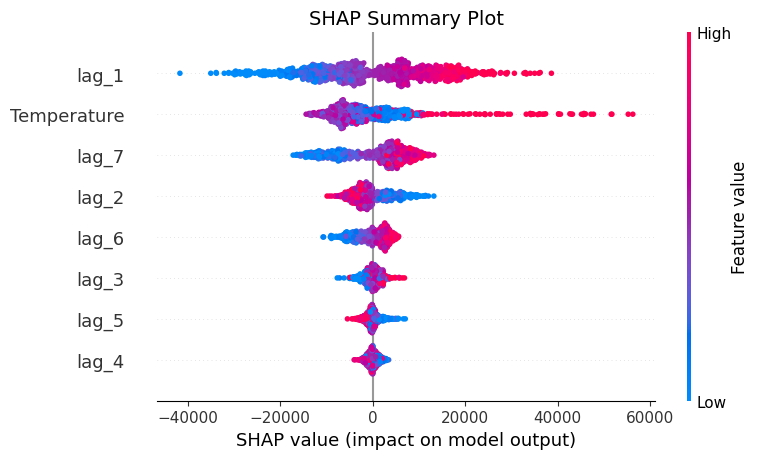

<Figure size 1200x300 with 0 Axes>

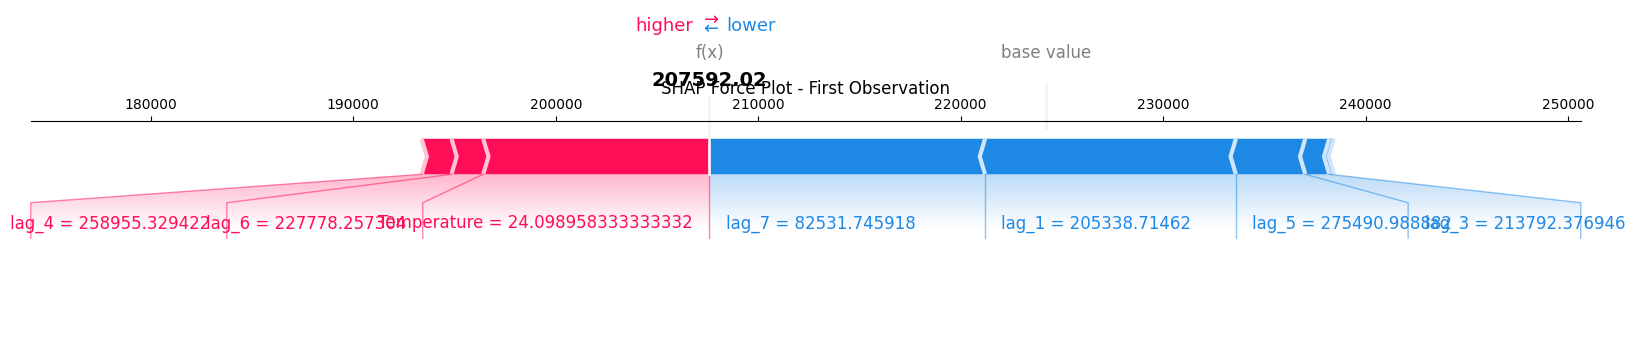

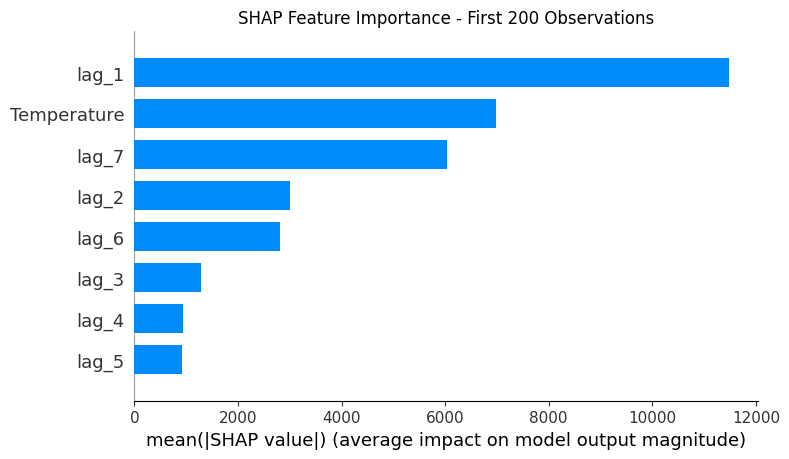

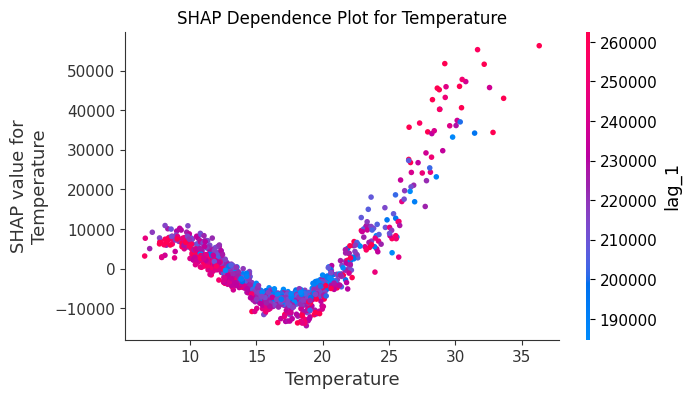


--- Hasil Prediksi 10 Langkah ke Depan ---


2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64


--- Matriks Fitur Input untuk Prediksi (X_predict) ---


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


<Figure size 1200x300 with 0 Axes>

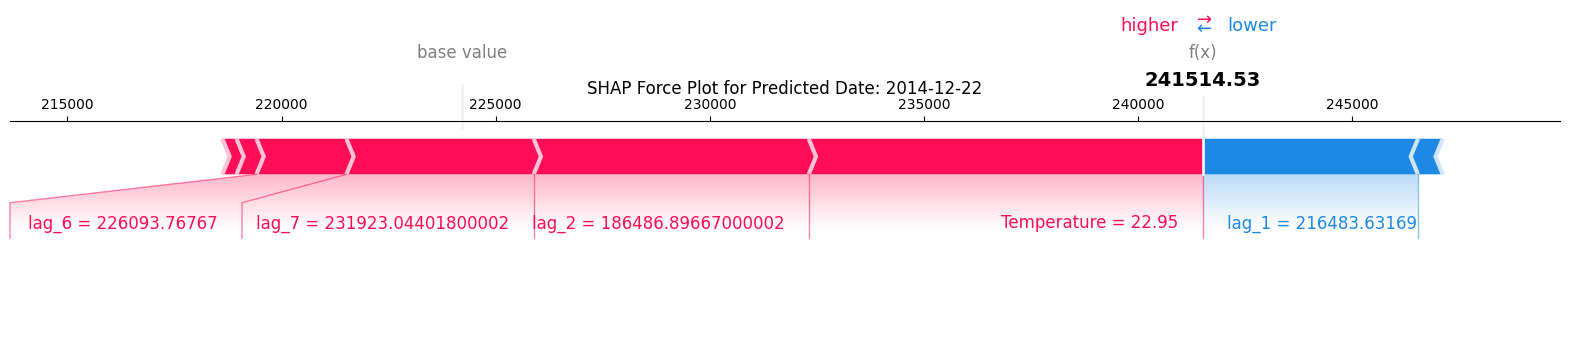


--- Hasil Tabel Permutation Importance ---


,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


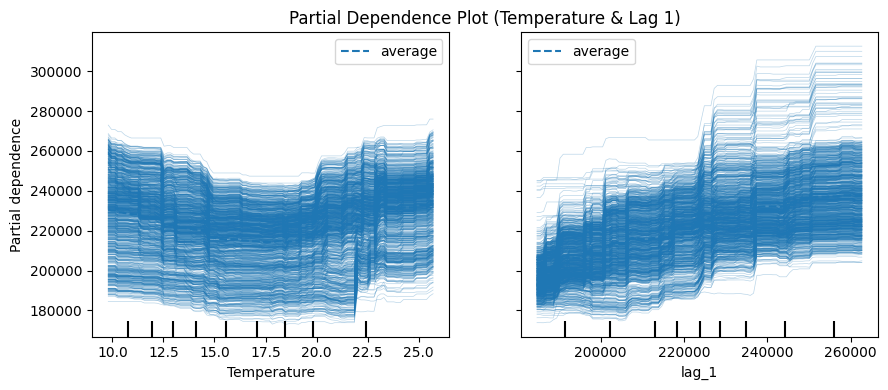

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# 1. Unduh Data
data = fetch_dataset(name="vic_electricity")
print("--- Data Mentah (3 Baris Pertama) ---")
display(data.head(3))

# 2. Agregasi ke Frekuensi Harian ('D')
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
print("\n--- Data Harian Setelah Agregasi ---")
display(data.head(3))

# 3. Pisahkan Data Latih (Train) dan Data Uji (Test)
data_train = data.loc[:'2014-12-21']
data_test = data.loc['2014-12-22':]

# 4. Buat Peramalan Multi-Langkah Rekursif (ForecasterRecursive)
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),
    lags      = 7
)
forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
print("\n--- Struktur Objek Forecaster ---")
display(forecaster)

# 5. Prediktor Penting (Gini Importance Bawaan Model)
print("\n--- Feature Importances Bawaan Model ---")
display(forecaster.get_feature_importances())

# 6. Buat Matriks Pelatihan Supervised Learning
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
print("\n--- Matriks Input Training (X_train) ---")
display(X_train.head(3))
print("\n--- Matriks Target Training (y_train) ---")
display(y_train.head(3))

# 7. Analisis SHAP (Global & Local Explainability)
shap.initjs()
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

# Plot ringkasan dampak fitur global (Beeswarm plot)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.show()

# Force Plot untuk SATU observasi pertama (lokal)
plt.figure(figsize=(12, 3))
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :], matplotlib=True, show=False)
plt.title("SHAP Force Plot - First Observation", fontsize=12, pad=20)
plt.show()

# Plot tipe 'bar' untuk melihat kontribusi rata-rata dari 200 observasi pertama secara masal
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values[:200, :], X_train.iloc[:200, :], plot_type="bar", show=False)
plt.title("SHAP Feature Importance - First 200 Observations", fontsize=12)
plt.tight_layout()
plt.show()

# Dependence Plot khusus untuk fitur Suhu (Temperature)
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax, show=False)
plt.title("SHAP Dependence Plot for Temperature", fontsize=12)
plt.show()

# 8. Melakukan Prediksi / Peramalan (Forecasting)
prediksi = forecaster.predict(steps=10, exog=data_test['Temperature'].iloc[:10])
print("\n--- Hasil Prediksi 10 Langkah ke Depan ---")
display(prediksi)

# 9. Buat Matriks Input untuk Metode Prediksi (X_predict)
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'].iloc[:10])
print("\n--- Matriks Fitur Input untuk Prediksi (X_predict) ---")
display(X_predict)

# 10. SHAP Force Plot untuk Prediksi Tanggal Tertentu
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values_predict = explainer.shap_values(X_predict)

plt.figure(figsize=(12, 3))
shap.force_plot(
    explainer.expected_value,
    shap_values_predict[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :],
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot for Predicted Date: {predicted_date}", fontsize=12, pad=20)
plt.show()

# 11. Analisis Permutation Importance (Global)
r = permutation_importance(
    estimator    = forecaster.estimator,
    X            = X_train,
    y            = y_train,
    n_repeats    = 3,
    max_samples  = 0.5,
    random_state = 123
)
importances = pd.DataFrame({
    'feature': X_train.columns,
    'mean_importance': r.importances_mean,
    'std_importance': r.importances_std
}).sort_values('mean_importance', ascending=False)
print("\n--- Hasil Tabel Permutation Importance ---")
display(importances)

# 12. Scikit-learn Partial Dependence Plots (PDP)
fig, ax = plt.subplots(figsize=(9, 4))
display_pdp = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax
)
ax.set_title("Partial Dependence Plot (Temperature & Lag 1)")
fig.tight_layout()
plt.show()